# Explorando Imágenes de Fondo de Ojo como Matrices

### Explorando la imagen como matriz

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

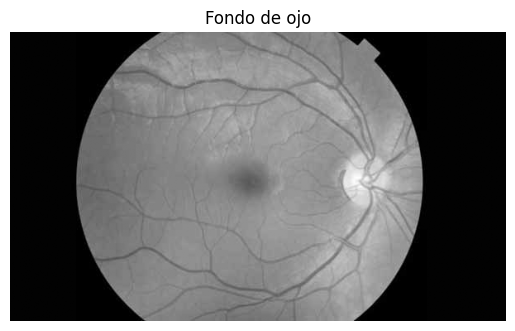

In [4]:
# Cargar imagen
url='https://dashboard.oftalvist.es/public/blog/257/que-es-la-macula.jpeg'
resp=urllib.request.urlopen(url) #Guarda respuesta que contiene los datos del archivo
image=np.asarray(bytearray(resp.read()),dtype="uint8") #Lee la imagen descargada de internet y lo convierte en un arreglo númerico que OpenCV pueda interpretar
imagen=cv2.imdecode(image,cv2.IMREAD_GRAYSCALE) #Convierte los bytes descargados en una imagen real y la carga en escala de grises

# Mostrar imagen
plt.imshow(imagen, cmap='gray') #Muestra la imagen en tonos grises
plt.title('Fondo de ojo')
plt.axis("off")
plt.show()

### Tamaño de la imagen

In [5]:
imagen.shape

(350, 600)

##### Una matriz es una tabla de números organizada en filas y columnas.
##### En procesamiento digital de imágenes, una imagen en escala de grises se representa como una matriz bidimensional, donde cada elemento corresponde a un píxel.
##### Las filas representan la altura de la imagen y las columnas representan el ancho.
##### El valor almacenado en cada posición de la matriz indica la intensidad luminosa del píxel, en un rango de 0 a 255, donde 0 corresponde al negro y 255 al blanco.

### Valor de pixel (200, 200)

In [6]:
valor = imagen[200, 200]
print(valor)

104


##### Se fue a la fila 200, columna 200 y mostro el pixel que se encuentra ahí.
##### Es el número de la intensidad del pixel, en este caso 104 es un tono gris medio, más cerca del 0, que del 255.

### Valor máximo y mínimo de intensidad de imagen

In [9]:
minimo = imagen.min()
maximo = imagen.max()
print("Valor minimo =", minimo)
print("Valor maximo =", maximo)

Valor minimo = 0
Valor maximo = 206


##### El 0 significa que en la imagen hay mínimo un pixel negro, mientras que el 206 indica que no hay pixeles totalmente blancos, pero sí hay pixeles claros. 

### Manipulación directa de la matriz

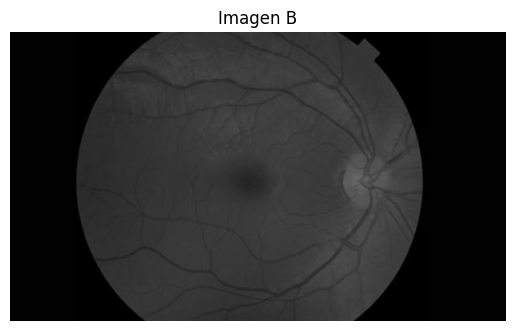

In [19]:
# Obtener dimensiones de la imagen original A
filas, columnas = imagen.shape # Para saber hasta dónde recorren los for

# Crear una nueva matriz B del mismo tamaño, llena de ceros
B = np.zeros((filas, columnas), dtype=np.uint8)

# Recorrer cada píxel de la imagen A
for i in range(filas):
    for j in range(columnas):
        B[i, j] = int(0.5 * imagen[i, j]) # Toma el valor del píxel original en imagen[i, j], lo multiplica por 0.5 y lo guarda en B[i, j]
        # Se usa int para dejar los valores en enteros, no puede haber decimales

# Mostrar la nueva imagen B
plt.imshow(B, cmap='gray', vmin=0, vmax=255) # Hay que aclarar los valores mínimos y máximos para que aparezca con la reducción
plt.title('Imagen B')
plt.axis("off")
plt.show()

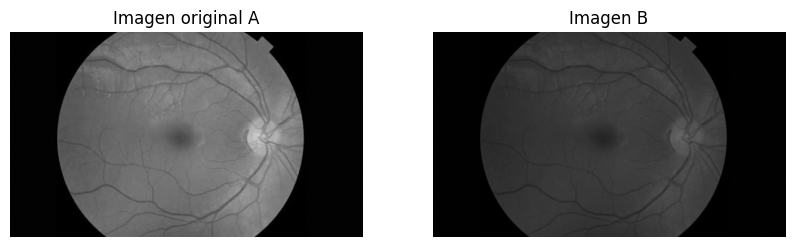

In [21]:
plt.figure(figsize=(10,4))

# Imagen original A
plt.subplot(1, 2, 1) # fila, columna, posición 
plt.imshow(imagen, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original A')
plt.axis("off")

# Imagen modificada B
plt.subplot(1, 2, 2)
plt.imshow(B, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen B')
plt.axis("off")

plt.show()


### 1. ¿Cómo cambió el brillo de la imagen?
##### La imagen B se ve más opaca comparada con la imagen A. Se ve mayor brillo en la imagen original.

### 2. ¿Qué pasó con la visibilidad de los vasos sanguíneos?
##### Los vasos sanguíneos siguen ahí, pero debido a que se obscurecieron más hace que visualemnte se vean menos. No es posible ver detalles de ellos en la imagen. 

### Transformación logarítmica 

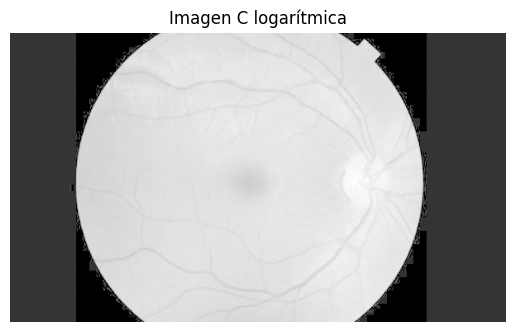

In [27]:
import math

# Crear matriz temporal para guardar la transformación logarítmica
C_log = np.zeros((filas, columnas), dtype=float) # dtype=float es porque logaritmo da resultados con decimal 

# Aplicar la transformación log10(A(i,j) + 1), es +1 porque en la matriz hay 0 y no existe log10(0)
for i in range(filas):
    for j in range(columnas):
        C_log[i, j] = math.log10(imagen[i, j] + 1)

# Obtener el valor mínimo y máximo de la imagen transformada, 0, 2.316
min_val = C_log.min()
max_val = C_log.max()

# Crear imagen final normalizada en rango [0,255]
C = np.zeros((filas, columnas), dtype=np.uint8)

# Normalizar manualmente al rango [0,255]
for i in range(filas):
    for j in range(columnas):
        C[i, j] = int(((C_log[i, j] - min_val) / (max_val - min_val)) * 255) # formula para normalizar

# Mostrar imagen logarítmica
plt.imshow(C, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen C logarítmica")
plt.axis("off")
plt.show()

### 1. ¿Qué regiones de la imagen se ven más claras?
##### Las regiones de baja intensidad o más oscuras de la imagen se observan más claras después de aplicar la transformación logarítmica. Esto ocurre porque el logaritmo amplifica los valores pequeños, mejorando la visibilidad de detalles en zonas oscuras.
### 2. ¿Qué pasó con las regiones muy brillantes?
##### Las regiones muy brillantes ya no resaltan tanto como antes. Se ven más suavizadas y con menos diferencia entre tonos claros, por lo que dejan de verse tan intensas en comparación con la imagen original.

### Análisis de histograma

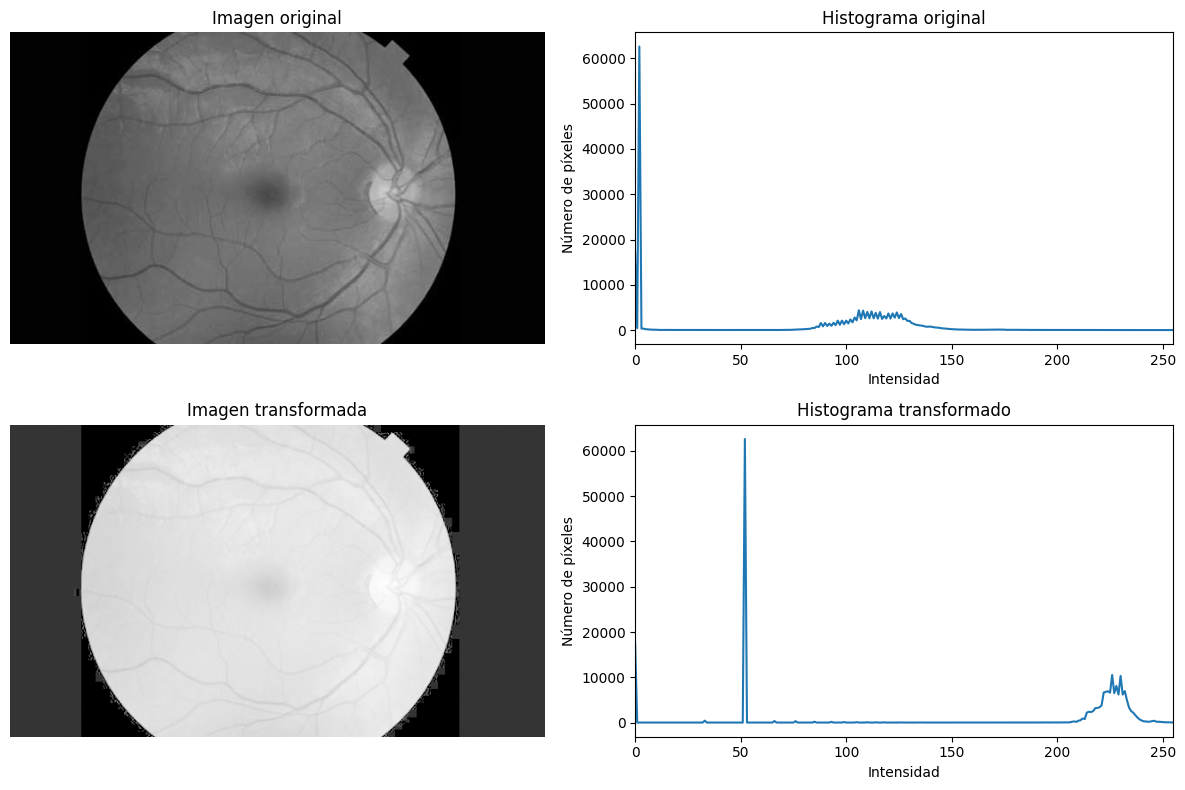

In [29]:
# Calcular histograma de la imagen original
hist_original = np.zeros(256, dtype=int)

for i in range(filas):
    for j in range(columnas):
        valor = imagen[i, j] # Obtiene el valor de la imagen
        hist_original[valor] += 1 #s suma 1 a esa intencidad

# Calcular histograma de la imagen transformada (B)
hist_transformada = np.zeros(256, dtype=int)

for i in range(filas):
    for j in range(columnas):
        valor = C[i, j]
        hist_transformada[valor] += 1

# Mostrar imágenes e histogramas
plt.figure(figsize=(12, 8))

# Imagen original
plt.subplot(2, 2, 1)
plt.imshow(imagen, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")

# Histograma original
plt.subplot(2, 2, 2)
plt.plot(hist_original) # dibuja la curva del histograma
plt.title("Histograma original")
plt.xlabel("Intensidad")
plt.ylabel("Número de píxeles")
plt.xlim(0, 255)

# Imagen transformada
plt.subplot(2, 2, 3)
plt.imshow(B, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen transformada")
plt.axis("off")

# Histograma transformado
plt.subplot(2, 2, 4)
plt.plot(hist_transformada)
plt.title("Histograma transformado")
plt.xlabel("Intensidad")
plt.ylabel("Número de píxeles")
plt.xlim(0, 255)

plt.tight_layout() # acomoda los suplot para que no queden encimados
plt.show()

##### En el histograma de la imagen transformada se observa un cambio en la distribución de intensidades respecto a la original. La transformación logarítmica hace que las zonas oscuras se aclaren más y que las zonas muy brillantes no resalten tanto, por lo que el histograma se redistribuye.

### Resaltando vasos sanguíneos

#### Transformación logarítmica → Normalización → Inversión → Umbralización

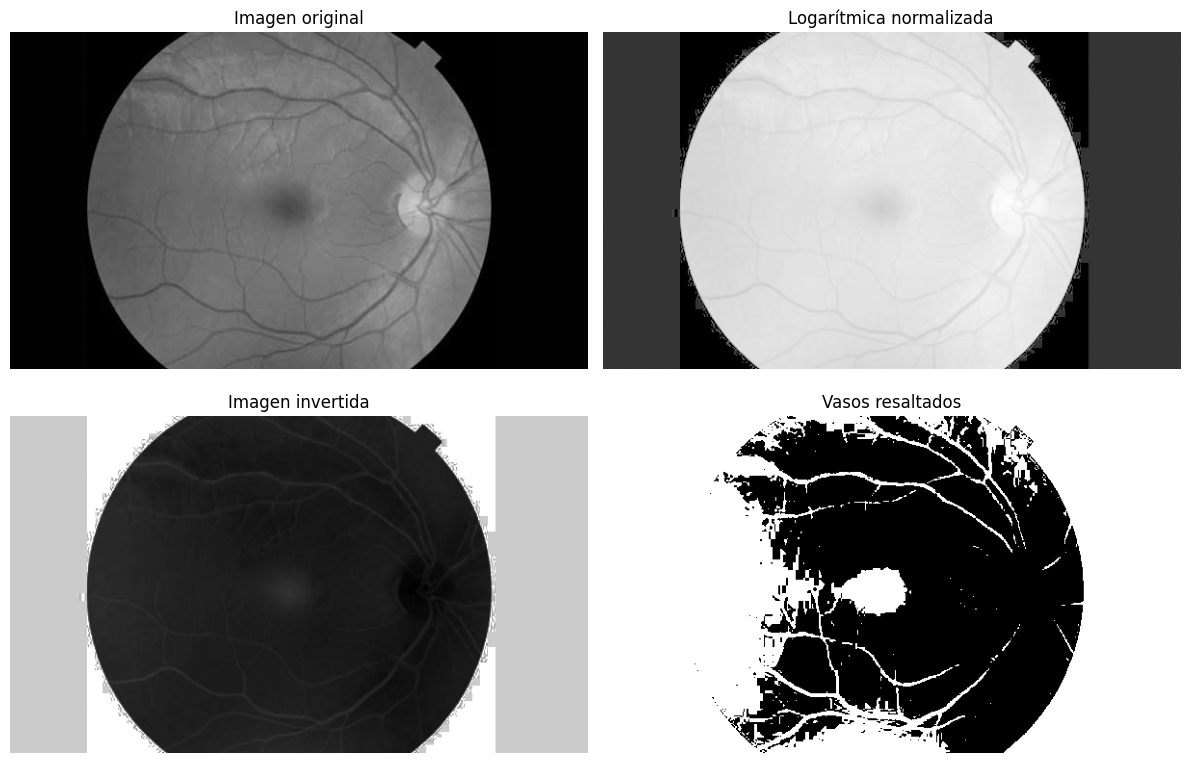

In [18]:
import math

# Paso 1: Obtener dimensiones de la imagen original
filas, columnas = imagen.shape

# Paso 2: Crear matriz para la transformación logarítmica
L = np.zeros((filas, columnas), dtype=float)

# Aplicar transformación logarítmica: L(i,j) = log10(A(i,j) + 1)
for i in range(filas):
    for j in range(columnas):
        L[i, j] = math.log10(imagen[i, j] + 1)

# Paso 3: Obtener mínimo y máximo de la imagen logarítmica
min_L = L.min()
max_L = L.max()

# Paso 4: Normalizar la imagen logarítmica al rango [0,255]
L_norm = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        L_norm[i, j] = int(((L[i, j] - min_L) / (max_L - min_L)) * 255)

# Paso 5: Invertir la imagen
I = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        I[i, j] = 255 - L_norm[i, j]

# Paso 6: Aplicar umbralización
T = 31

V = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        if I[i, j] > T:
            V[i, j] = 255
        else:
            V[i, j] = 0

# Paso 7: Mostrar resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(imagen, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(L_norm, cmap='gray', vmin=0, vmax=255)
plt.title("Logarítmica normalizada")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(I, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen invertida")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(V, cmap='gray', vmin=0, vmax=255)
plt.title("Vasos resaltados")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Invertir → Raíz cuadrada → Normalizar → Umbral por rango

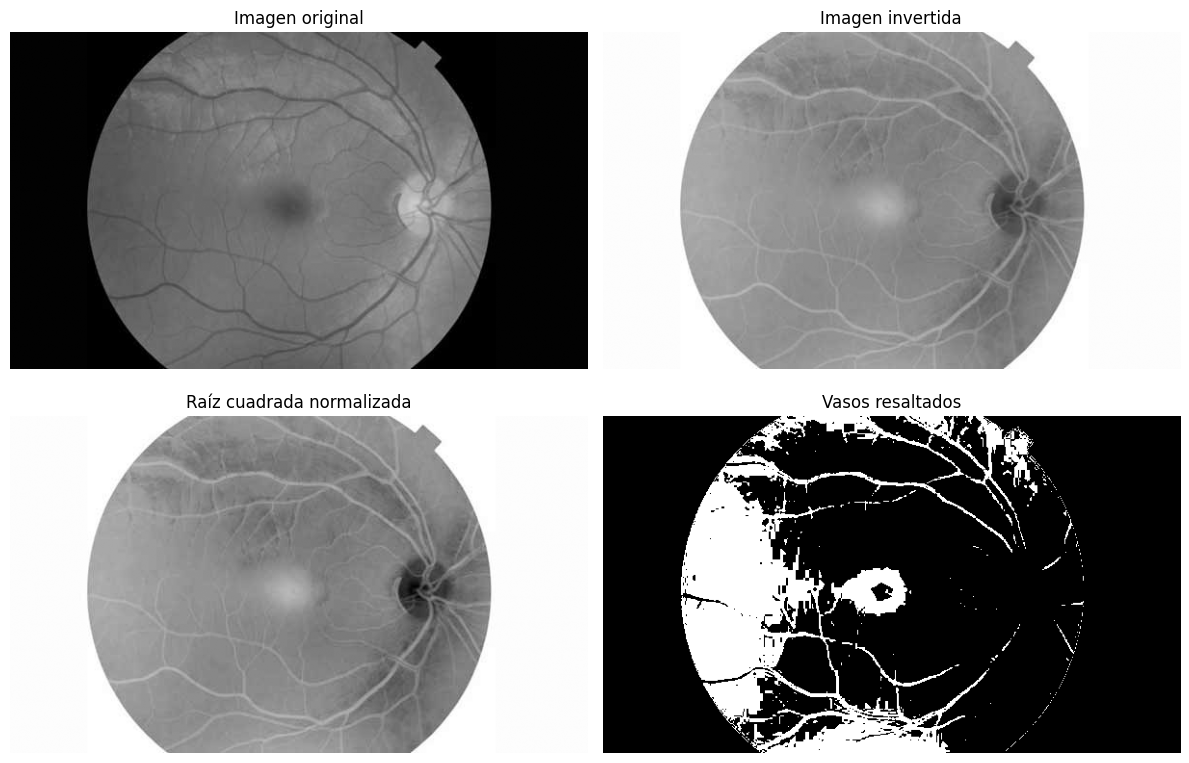

In [22]:
# Paso 1: Invertir la imagen original
I = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        I[i, j] = 255 - imagen[i, j]

# Paso 2: Aplicar raíz cuadrada
R = np.zeros((filas, columnas), dtype=float)

for i in range(filas):
    for j in range(columnas):
        R[i, j] = math.sqrt(I[i, j])

# Paso 3: Normalizar al rango [0,255]
min_R = R.min()
max_R = R.max()

R_norm = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        R_norm[i, j] = int(((R[i, j] - min_R) / (max_R - min_R)) * 255)

# Paso 4: Umbralización por rango (ajustable)
V = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        if imagen[i, j] > 20 and R_norm[i, j] > 145 and R_norm[i, j] < 175:
            V[i, j] = 255
        else:
            V[i, j] = 0

# Mostrar resultados
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(imagen, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(I, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen invertida")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(R_norm, cmap='gray', vmin=0, vmax=255)
plt.title("Raíz cuadrada normalizada")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(V, cmap='gray', vmin=0, vmax=255)
plt.title("Vasos resaltados")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Raíz cuadrada → Normalización → Umbralización

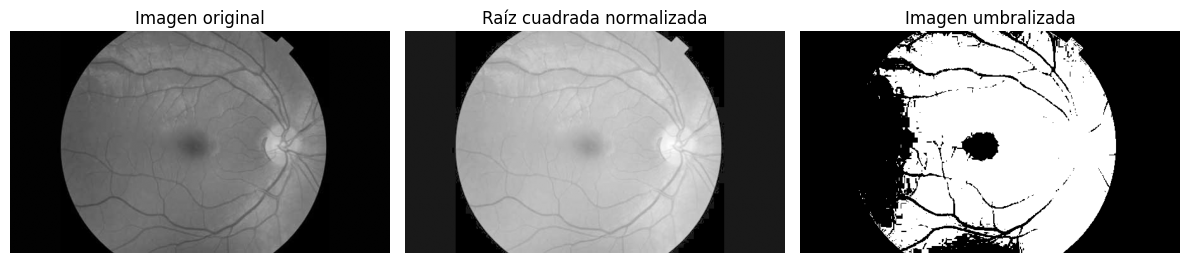

In [29]:
# Paso 1: Aplicar raíz cuadrada a la imagen original
R = np.zeros((filas, columnas), dtype=float)

for i in range(filas):
    for j in range(columnas):
        R[i, j] = math.sqrt(imagen[i, j])

# Paso 2: Normalizar al rango [0,255]
min_R = R.min()
max_R = R.max()

R_norm = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        R_norm[i, j] = int(((R[i, j] - min_R) / (max_R - min_R)) * 255)

# Paso 3: Umbralización simple
T = 181

V = np.zeros((filas, columnas), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        if R_norm[i, j] > T:
            V[i, j] = 255
        else:
            V[i, j] = 0

# Mostrar resultados
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.imshow(imagen, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(R_norm, cmap='gray', vmin=0, vmax=255)
plt.title("Raíz cuadrada normalizada")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen umbralizada")
plt.axis("off")

plt.tight_layout()
plt.show()

### 1. ¿Qué transformación ayudó más a resaltar los vasos?
##### La combinación que mejor permitió visualizar los vasos sanguíneos fue la inversión de la imagen seguida de umbralización.
### 2. ¿Por qué esa transformación funciona mejor?
##### Incrementó el contraste entre los vasos y el fondo retinal, facilitando la identificación de las estructuras vasculares principales.